In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [2]:
df = pl.read_parquet('video-transcripts.parquet')

In [3]:
# shape + unique values
print("shape:", df.shape)
print("n unique rows:", df.n_unique())
for j in range(df.shape[1]):
    print("n unique elements (" + df.columns[j] + "):", df[:,j].n_unique())

shape: (450, 4)
n unique rows: 450
n unique elements (video_id): 450
n unique elements (datetime): 446
n unique elements (title): 450
n unique elements (transcript): 438


In [4]:
print("Total number of title characters:", sum(len(df['title'][i]) for i in range(len(df))))
print("Total number of transcript characters:", sum(len(df['transcript'][i]) for i in range(len(df))))

Total number of title characters: 35822
Total number of transcript characters: 50281278


In [5]:
df = df.with_columns(pl.col('datetime').cast(pl.Datetime))
print(df.head())

shape: (5, 4)
┌─────────────┬─────────────────────┬──────────────────────────┬───────────────────────────────────┐
│ video_id    ┆ datetime            ┆ title                    ┆ transcript                        │
│ ---         ┆ ---                 ┆ ---                      ┆ ---                               │
│ str         ┆ datetime[μs]        ┆ str                      ┆ str                               │
╞═════════════╪═════════════════════╪══════════════════════════╪═══════════════════════════════════╡
│ _1f-o0nqpEI ┆ 2025-02-03 00:12:13 ┆ DeepSeek, China, OpenAI, ┆ - The following is a conversatio… │
│             ┆                     ┆ NVIDIA,…                 ┆                                   │
│ OHWnPOKh_S0 ┆ 2025-01-26 20:47:42 ┆ Marc Andreessen: Trump,  ┆ I mean look we're adding a trill… │
│             ┆                     ┆ Power, T…                ┆                                   │
│ Rz-4ulRKnz4 ┆ 2025-01-19 19:27:52 ┆ Jennifer Burns: Milton   ┆ - The follow

(array([113.,  65., 114.,  97.,  43.,  11.,   5.,   1.,   0.,   1.]),
 array([3.000000e+00, 4.824920e+04, 9.649540e+04, 1.447416e+05,
        1.929878e+05, 2.412340e+05, 2.894802e+05, 3.377264e+05,
        3.859726e+05, 4.342188e+05, 4.824650e+05]),
 <BarContainer object of 10 artists>)

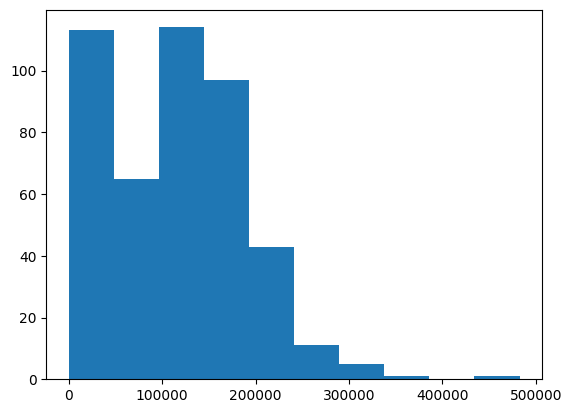

In [6]:
plt.hist(df['transcript'].str.len_chars())


(array([  2.,   1.,  18.,  24.,  56.,  39.,  47.,  67.,  95., 101.]),
 array([ 13. ,  22.5,  32. ,  41.5,  51. ,  60.5,  70. ,  79.5,  89. ,
         98.5, 108. ]),
 <BarContainer object of 10 artists>)

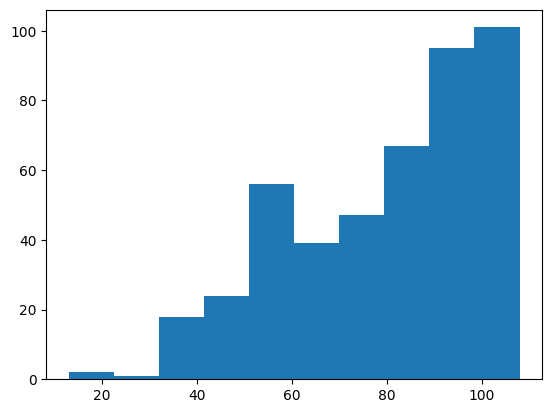

In [7]:
plt.hist(df['title'].str.len_chars())

In [8]:
print(df['title'][3])
print(df['transcript'][3])

Volodymyr Zelenskyy: Ukraine, War, Peace, Putin, Trump, NATO, and Freedom | Lex Fridman Podcast #456
- I hope the Kyiv
airport will open soon. Then it will... it will
be easier to fly in. - Yes, I think that the war will end, and President Trump may be the
first leader to travel here by airplane. I think it would be, it would
be symbolic, by airplane. - Again, January 25th,
around that date, right? Flying in, meeting
the Air Force One. - Oh that would be cool. - There is a perception of corruption. People like Donald Trump and Elon Musk
really care, uh, about fighting corruption. What can you say to them to
gain their trust that the money is going towards this fight for
freedom, towards the war effort? - In most of cases, we did not receive
money, we received weapons. And where we saw risks that
something could be happening with weapons, we cracked down
hard on everyone. And believe me, this is
not only about Ukraine. Everywhere along the supply chain,
there are some or other people an

In [9]:
df.write_parquet('video-transcripts.parquet')